In [74]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [75]:
data = pd.read_excel("student.xlsx")

In [76]:
data.head()

,STUDENT IDENTIFIER,STDNT_AGE,STDNT_GENDER,STDNT_BACKGROUND,IN_STATE_FLAG,INTERNATIONAL_STS,STDNT_MAJOR,STDNT_MINOR,STDNT_TEST_ENTRANCE1,STDNT_TEST_ENTRANCE2,...,DEGREE_GROUP_CD,DEGREE_GROUP_DESC,FIRST_TERM_ATTEMPT_HRS,FIRST_TERM_EARNED_HRS,SECOND_TERM_ATTEMPT_HRS,SECOND_TERM_EARNED_HRS,GROSS_FIN_NEED,COST_OF_ATTEND,EST_FAM_CONTRIBUTION,UNMET_NEED
0,7808615,18,F,BGD 1,Y,N,Undeclared,N,NaN,1150.0,...,B,Bachelors,16,16,14.0,14.0,0,0,0,0.0
1,7830063,19,F,BGD 1,N,N,Undeclared,N,26.0,NaN,...,B,Bachelors,18,18,18.0,18.0,570000,1355760,785760,459300.0
2,7847538,18,M,BGD 1,Y,N,Mathematics,N,NaN,1020.0,...,B,Bachelors,15,15,14.0,14.0,0,0,0,0.0
3,8006429,18,M,BGD 1,Y,N,Undeclared,N,NaN,1210.0,...,B,Bachelors,13,13,14.0,14.0,0,0,0,0.0
4,7962680,18,F,BGD 1,Y,N,Art,N,NaN,1200.0,...,B,Bachelors,12,12,12.0,12.0,835920,1355760,519840,278340.0


In [77]:
data.isnull().sum()

STUDENT IDENTIFIER             0
STDNT_AGE                      0
STDNT_GENDER                   0
STDNT_BACKGROUND               0
IN_STATE_FLAG                  0
INTERNATIONAL_STS              0
STDNT_MAJOR                    0
STDNT_MINOR                    0
STDNT_TEST_ENTRANCE1        2294
STDNT_TEST_ENTRANCE2         908
STDNT_TEST_ENTRANCE_COMB     518
FIRST_TERM                     0
CORE_COURSE_NAME_1_F           0
CORE_COURSE_GRADE_1_F          0
CORE_COURSE_NAME_2_F          99
CORE_COURSE_GRADE_2_F         99
CORE_COURSE_NAME_3_F         565
CORE_COURSE_GRADE_3_F        565
CORE_COURSE_NAME_4_F        1597
CORE_COURSE_GRADE_4_F       1597
CORE_COURSE_NAME_5_F        2755
CORE_COURSE_GRADE_5_F       2755
CORE_COURSE_NAME_6_F        3272
CORE_COURSE_GRADE_6_F       3272
SECOND_TERM                    0
CORE_COURSE_NAME_1_S         157
CORE_COURSE_GRADE_1_S        232
CORE_COURSE_NAME_2_S         439
CORE_COURSE_GRADE_2_S        439
CORE_COURSE_NAME_3_S        1038
CORE_COURS

In [78]:
data.columns

Index(['STUDENT IDENTIFIER', 'STDNT_AGE', 'STDNT_GENDER', 'STDNT_BACKGROUND',
       'IN_STATE_FLAG', 'INTERNATIONAL_STS', 'STDNT_MAJOR', 'STDNT_MINOR',
       'STDNT_TEST_ENTRANCE1', 'STDNT_TEST_ENTRANCE2',
       'STDNT_TEST_ENTRANCE_COMB', 'FIRST_TERM', 'CORE_COURSE_NAME_1_F',
       'CORE_COURSE_GRADE_1_F', 'CORE_COURSE_NAME_2_F',
       'CORE_COURSE_GRADE_2_F', 'CORE_COURSE_NAME_3_F',
       'CORE_COURSE_GRADE_3_F', 'CORE_COURSE_NAME_4_F',
       'CORE_COURSE_GRADE_4_F', 'CORE_COURSE_NAME_5_F',
       'CORE_COURSE_GRADE_5_F', 'CORE_COURSE_NAME_6_F',
       'CORE_COURSE_GRADE_6_F', 'SECOND_TERM', 'CORE_COURSE_NAME_1_S',
       'CORE_COURSE_GRADE_1_S', 'CORE_COURSE_NAME_2_S',
       'CORE_COURSE_GRADE_2_S', 'CORE_COURSE_NAME_3_S',
       'CORE_COURSE_GRADE_3_S', 'CORE_COURSE_NAME_4_S',
       'CORE_COURSE_GRADE_4_S', 'CORE_COURSE_NAME_5_S',
       'CORE_COURSE_GRADE_5_S', 'CORE_COURSE_NAME_6_S',
       'CORE_COURSE_GRADE_6_S', 'HOUSING_STS', 'RETURNED_2ND_YR',
       'DISTANCE_FROM_

In [79]:
data['FIRST_TERM_Hr']=data['FIRST_TERM_EARNED_HRS']/data['FIRST_TERM_ATTEMPT_HRS']
data['SECOND_TERM_Hr']=data['SECOND_TERM_EARNED_HRS']/data['SECOND_TERM_ATTEMPT_HRS']

In [80]:
data.isna().sum()

STUDENT IDENTIFIER             0
STDNT_AGE                      0
STDNT_GENDER                   0
STDNT_BACKGROUND               0
IN_STATE_FLAG                  0
INTERNATIONAL_STS              0
STDNT_MAJOR                    0
STDNT_MINOR                    0
STDNT_TEST_ENTRANCE1        2294
STDNT_TEST_ENTRANCE2         908
STDNT_TEST_ENTRANCE_COMB     518
FIRST_TERM                     0
CORE_COURSE_NAME_1_F           0
CORE_COURSE_GRADE_1_F          0
CORE_COURSE_NAME_2_F          99
CORE_COURSE_GRADE_2_F         99
CORE_COURSE_NAME_3_F         565
CORE_COURSE_GRADE_3_F        565
CORE_COURSE_NAME_4_F        1597
CORE_COURSE_GRADE_4_F       1597
CORE_COURSE_NAME_5_F        2755
CORE_COURSE_GRADE_5_F       2755
CORE_COURSE_NAME_6_F        3272
CORE_COURSE_GRADE_6_F       3272
SECOND_TERM                    0
CORE_COURSE_NAME_1_S         157
CORE_COURSE_GRADE_1_S        232
CORE_COURSE_NAME_2_S         439
CORE_COURSE_GRADE_2_S        439
CORE_COURSE_NAME_3_S        1038
CORE_COURS

In [81]:
x=data.drop(['STUDENT IDENTIFIER','CORE_COURSE_NAME_4_F','CORE_COURSE_GRADE_4_F',
             'CORE_COURSE_NAME_5_F','CORE_COURSE_GRADE_5_F','CORE_COURSE_NAME_6_F','CORE_COURSE_GRADE_6_F',
             'CORE_COURSE_NAME_4_S','CORE_COURSE_GRADE_4_S','CORE_COURSE_GRADE_5_S','CORE_COURSE_NAME_5_S',
             'CORE_COURSE_GRADE_6_S','CORE_COURSE_NAME_6_S','RETURNED_2ND_YR','FIRST_TERM_ATTEMPT_HRS',
             'FIRST_TERM_EARNED_HRS','SECOND_TERM_ATTEMPT_HRS','SECOND_TERM_EARNED_HRS','FATHER_HI_EDU_CD',
             'MOTHER_HI_EDU_CD','DEGREE_GROUP_CD','CORE_COURSE_NAME_3_F',
             'CORE_COURSE_GRADE_3_F','CORE_COURSE_NAME_3_S',
             'CORE_COURSE_GRADE_3_S','CORE_COURSE_NAME_4_F',
             'CORE_COURSE_GRADE_4_F','CORE_COURSE_NAME_4_S',
             'CORE_COURSE_GRADE_4_S','CORE_COURSE_NAME_1_F','CORE_COURSE_NAME_2_F','CORE_COURSE_NAME_2_S','CORE_COURSE_NAME_1_S','HIGH_SCHL_NAME'],axis=1)

In [82]:
x.isna().sum()

STDNT_AGE                      0
STDNT_GENDER                   0
STDNT_BACKGROUND               0
IN_STATE_FLAG                  0
INTERNATIONAL_STS              0
STDNT_MAJOR                    0
STDNT_MINOR                    0
STDNT_TEST_ENTRANCE1        2294
STDNT_TEST_ENTRANCE2         908
STDNT_TEST_ENTRANCE_COMB     518
FIRST_TERM                     0
CORE_COURSE_GRADE_1_F          0
CORE_COURSE_GRADE_2_F         99
SECOND_TERM                    0
CORE_COURSE_GRADE_1_S        232
CORE_COURSE_GRADE_2_S        439
HOUSING_STS                    0
DISTANCE_FROM_HOME            25
HIGH_SCHL_GPA                 53
FATHER_HI_EDU_DESC             0
MOTHER_HI_EDU_DESC             0
DEGREE_GROUP_DESC              0
GROSS_FIN_NEED                 0
COST_OF_ATTEND                 0
EST_FAM_CONTRIBUTION           0
UNMET_NEED                     0
FIRST_TERM_Hr                  0
SECOND_TERM_Hr               209
dtype: int64

In [84]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STDNT_AGE                 3400 non-null   int64  
 1   STDNT_GENDER              3400 non-null   str    
 2   STDNT_BACKGROUND          3400 non-null   str    
 3   IN_STATE_FLAG             3400 non-null   str    
 4   INTERNATIONAL_STS         3400 non-null   str    
 5   STDNT_MAJOR               3400 non-null   str    
 6   STDNT_MINOR               3400 non-null   str    
 7   STDNT_TEST_ENTRANCE1      1106 non-null   float64
 8   STDNT_TEST_ENTRANCE2      2492 non-null   float64
 9   STDNT_TEST_ENTRANCE_COMB  2882 non-null   float64
 10  FIRST_TERM                3400 non-null   int64  
 11  CORE_COURSE_GRADE_1_F     3400 non-null   str    
 12  CORE_COURSE_GRADE_2_F     3301 non-null   str    
 13  SECOND_TERM               3400 non-null   int64  
 14  CORE_COURSE_GRADE_1

In [87]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame
categorical_cols = [
    'STDNT_GENDER', 'STDNT_BACKGROUND', 'IN_STATE_FLAG', 'INTERNATIONAL_STS', 
    'STDNT_MAJOR', 'STDNT_MINOR', 'CORE_COURSE_GRADE_1_F', 'CORE_COURSE_GRADE_2_F', 
    'CORE_COURSE_GRADE_1_S', 'CORE_COURSE_GRADE_2_S', 'HOUSING_STS', 
    'FATHER_HI_EDU_DESC', 'MOTHER_HI_EDU_DESC', 'DEGREE_GROUP_DESC'
]

# Initialize LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    # Fill NaN with a placeholder to avoid errors during encoding
    x[col] = x[col].fillna('Unknown').astype(str)
    
    # Apply Label Encoding
    x[col] = le.fit_transform(x[col])

# Verify the changes
print(x[categorical_cols].head())

   STDNT_GENDER  STDNT_BACKGROUND  IN_STATE_FLAG  INTERNATIONAL_STS  \
0             0                 0              1                  0   
1             0                 0              0                  0   
2             1                 0              1                  0   
3             1                 0              1                  0   
4             0                 0              1                  0   

   STDNT_MAJOR  STDNT_MINOR  CORE_COURSE_GRADE_1_F  CORE_COURSE_GRADE_2_F  \
0           49           21                      0                      0   
1           49           21                      0                      0   
2           29           21                      0                      0   
3           49           21                      0                      0   
4           12           21                      0                      0   

   CORE_COURSE_GRADE_1_S  CORE_COURSE_GRADE_2_S  HOUSING_STS  \
0                      0                      

In [88]:
x.fillna(x.mean(),inplace=True)

,STDNT_AGE,STDNT_GENDER,STDNT_BACKGROUND,IN_STATE_FLAG,INTERNATIONAL_STS,STDNT_MAJOR,STDNT_MINOR,STDNT_TEST_ENTRANCE1,STDNT_TEST_ENTRANCE2,STDNT_TEST_ENTRANCE_COMB,...,HIGH_SCHL_GPA,FATHER_HI_EDU_DESC,MOTHER_HI_EDU_DESC,DEGREE_GROUP_DESC,GROSS_FIN_NEED,COST_OF_ATTEND,EST_FAM_CONTRIBUTION,UNMET_NEED,FIRST_TERM_Hr,SECOND_TERM_Hr
0,18,0,0,1,0,49,21,20.660036,1150.000000,1150.0,...,4.00,3,3,1,0,0,0,0.0,1.000000,1.000000
1,19,0,0,0,0,49,21,26.000000,965.092295,1190.0,...,2.89,0,0,1,570000,1355760,785760,459300.0,1.000000,1.000000
2,18,1,0,1,0,29,21,20.660036,1020.000000,1030.0,...,3.39,1,4,1,0,0,0,0.0,1.000000,1.000000
3,18,1,0,1,0,49,21,20.660036,1210.000000,1220.0,...,2.93,0,0,1,0,0,0,0.0,1.000000,1.000000
4,18,0,0,1,0,12,21,20.660036,1200.000000,1190.0,...,3.86,0,1,1,835920,1355760,519840,278340.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395,18,0,3,0,0,35,21,20.660036,800.000000,790.0,...,3.93,3,3,1,0,0,0,0.0,1.000000,0.812500
3396,18,0,0,1,0,34,21,20.000000,965.092295,950.0,...,2.69,3,3,1,0,0,0,0.0,0.692308,0.872315
3397,18,0,3,1,0,34,21,20.660036,1020.000000,1030.0,...,2.76,4,1,1,0,945840,1288980,0.0,0.428571,0.872315
3398,18,0,2,1,0,24,21,21.000000,965.092295,990.0,...,3.56,1,0,1,0,269100,0,-231720.0,0.750000,0.872315


In [89]:
y=data["RETURNED_2ND_YR"]

In [90]:
data['RETURNED_2ND_YR'].value_counts()

RETURNED_2ND_YR
1    2677
0     723
Name: count, dtype: int64

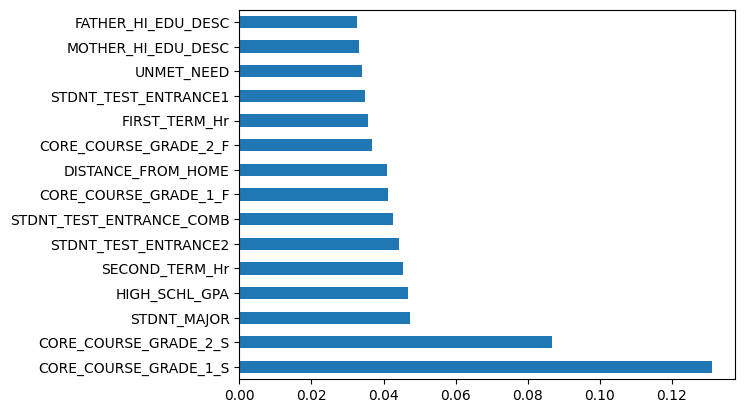

In [91]:
#import libraries
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
#Fit the model
model = ExtraTreesClassifier()
model.fit(x,y)
#plot graph of feature importances
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.show()

In [95]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,random_state=0)

In [97]:
print("x train shape is : ",Xtrain.shape)
print("x test shape is : ",Xtest.shape)
print("y train shape is : ",ytrain.shape)
print("y test shape is : ",ytest.shape) 

x train shape is :  (2720, 28)
x test shape is :  (680, 28)
y train shape is :  (2720,)
y test shape is :  (680,)


In [93]:
from sklearn.preprocessing import StandardScaler
scaler_SZ=StandardScaler() # Standarization

In [94]:
scaled_xtrain=scaler_SZ.fit_transform(Xtrain)
scaled_xtest=scaler_SZ.transform(Xtest)

In [99]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
grid={"C":np.logspace(-3,4,10), "penalty":["l1","l2"]}# l1 lasso l2 ridge
logreg=LogisticRegression(max_iter=2000)
logreg_cv=GridSearchCV(logreg,grid,cv=10,n_jobs=-1)
logreg_cv.fit(scaled_xtrain,ytrain)

print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(0.005994842503189409), 'penalty': 'l2'}
accuracy : 0.8272058823529413


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
100 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\moham\App

In [104]:
logreg2=LogisticRegression(C=0.005994842503189409,penalty="l2")
logreg2.fit(scaled_xtrain,ytrain)
y_pred=logreg2.predict(scaled_xtest)


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [105]:
from sklearn.metrics import accuracy_score

accuracy score of the model is :  0.8441176470588235
              precision    recall  f1-score   support

           0       0.78      0.25      0.38       129
           1       0.85      0.98      0.91       551

    accuracy                           0.84       680
   macro avg       0.81      0.62      0.64       680
weighted avg       0.84      0.84      0.81       680



<Axes: >

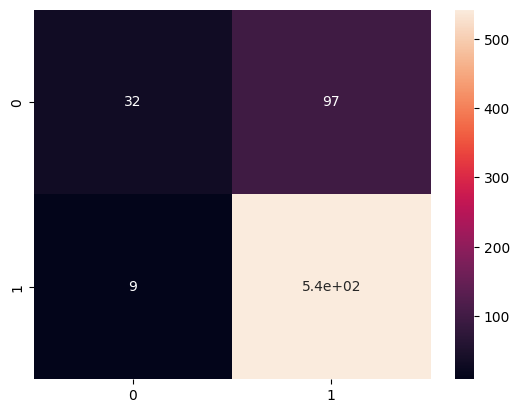

In [106]:
accuracy_score_c_test = accuracy_score(ytest,y_pred)
print("accuracy score of the model is : ",accuracy_score_c_test)
from sklearn.metrics import classification_report
print(classification_report(ytest,y_pred))
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest,y_pred)
sns.heatmap(cm,annot=True)